# Project 3 – Transportation Data Visualization & IDM Simulation
**Client:** Federal Highway Administration (FHWA)  
**Team:** Jacob Kosmicki, Ryder, Caden, Mehgan  
**Course:** CIVE 202  
**Date:** March 2026

---

## Notebook Layout

| Section | Description | Dataset |
|---------|-------------|---------|
| **1** | Package Imports & Global Settings | — |
| **2** | Load and Inspect Datasets | NHTS & NGSIM |
| **3** | NHTS Visualizations (bar chart, histogram, boxplot) | NHTS |
| **4** | NGSIM Time-Series Visualizations (speed, acceleration, position, gap, dashboard) | NGSIM |
| **5** | Intelligent Driver Model (IDM) Simulation | NGSIM |
| **6** | AI Use Citation | — |

---

## Section 1: Package Imports and Global Settings

In [ ]:
# Let import the important packages to be used here. 

import pandas as pd       # for reading CSV files and manipulating dataframes
import numpy as np        # for numerical operations like arrays and math functions
import matplotlib.pyplot as plt  # for creating plots and figures
import seaborn as sns     # for higher-level statistical plotting built on matplotlib

# Set clean visual style for all our plots
sns.set_style('whitegrid')
sns.set_palette('deep')

---
## Section 2: Load and Inspect Datasets

### 2.1 – Load the NHTS Dataset

In [ ]:
# Load in the National Household Travel Survey data from CSV
nhts_data = pd.read_csv('NHTS.csv')

nhts_data.head()

,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015
1,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,3,No,NaN,NaN,Gas,2019
2,9000013016,New England,Northeast,2,"$75,000 to $99,999",2,2,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Toyota,11,No,NaN,NaN,Gas,2011
3,9000013039,New England,Northeast,2,"$75,000 to $99,999",4,1,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Nissan/Datsun,7,No,NaN,NaN,Gas,2015
4,9000013041,New England,Northeast,1,"$175,000 or more",1,1,"Townhome, Condo",Urban,1,...,In an urban area,Automobile/car/stationwagon,No,BMV,8,No,NaN,NaN,Gas,2014


In [3]:
# Print all column names so we know what variables are available
print("NHTS Columns:", list(nhts_data.columns))
print(f"\nDataset size: {nhts_data.shape[0]} rows x {nhts_data.shape[1]} columns")

# Show data types and non-null counts for every column
nhts_data.info()

NHTS Columns: ['household_id', 'census_division', 'census_region', 'driver_count', 'household_income', 'household_size', 'household_workers', 'home_type', 'household_location', 'number_adults_household', 'vehicles_per_household', 'travel_date', 'travel_day', 'urban', 'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial', 'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year']

Dataset size: 14684 rows x 23 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14684 entries, 0 to 14683
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   household_id             14684 non-null  int64 
 1   census_division          14684 non-null  object
 2   census_region            14684 non-null  object
 3   driver_count             14684 non-null  int64 
 4   household_income         14684 non-null  object
 5   household_size           14684 non-null  int64 
 6   household_work

In [4]:
# Use .describe() to get summary statistics for all numeric columns
# This tells us the count, mean, std, min, max, and quartiles
nhts_data.describe()

,household_id,driver_count,household_size,household_workers,number_adults_household,vehicles_per_household,travel_date,vehicle_age,vehicle_year
count,1.468400e+04,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000
mean,9.000113e+09,2.014165,2.558090,1.179447,2.061223,2.534323,202211.722623,10.174271,2011.866658
std,5.936829e+04,0.814926,1.333751,0.984043,0.812286,1.436046,20.578951,7.959353,8.009252
min,9.000013e+09,0.000000,1.000000,0.000000,1.000000,1.000000,202201.000000,1.000000,1982.000000
25%,9.000057e+09,2.000000,2.000000,0.000000,2.000000,2.000000,202204.000000,4.000000,2007.000000
50%,9.000107e+09,2.000000,2.000000,1.000000,2.000000,2.000000,202208.000000,8.000000,2014.000000
75%,9.000166e+09,2.000000,3.000000,2.000000,2.000000,3.000000,202211.000000,15.000000,2018.000000
max,9.000218e+09,7.000000,10.000000,6.000000,8.000000,17.000000,202301.000000,40.000000,2023.000000


In [ ]:

nhts_data.isnull().sum()

household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64

### 2.2 – Load the NGSIM Dataset

In [6]:
# Load the NGSIM dataset
ngsim_data = pd.read_csv('NGSIM.csv')

# Print the dataset and show its attributes
print(ngsim_data.head())
print(ngsim_data.columns)

   Time  leader_position(m)  follower_position(m)  leader_speed(m/s)  \
0   0.1              26.654                0.0000             14.054   
1   0.2              28.060                1.4484             14.164   
2   0.3              29.476                2.8965             14.063   
3   0.4              30.882                4.3443             13.835   
4   0.5              32.266                5.7927             13.746   

   follower_speed(m/s)  leader_acc(m/s^2)  follower_acc(m/s^2)  \
0               14.484            1.09730        -3.048000e-02   
1               14.481           -1.00580        -3.048000e-02   
2               14.478           -2.28600         6.096000e-02   
3               14.484           -0.88392        -3.048000e-02   
4               14.481            0.85344         1.780000e-13   

   trajectory_number  
0                  1  
1                  1  
2                  1  
3                  1  
4                  1  
Index(['Time', 'leader_position(

In [7]:
# Understanding the Data Structure
print("Columns in dataset:", ngsim_data.columns)
print("Dataset info:")
print(ngsim_data.info())

Columns in dataset: Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  8166 non-null   float64
 1   leader_position(m)    8166 non-null   float64
 2   follower_position(m)  8166 non-null   float64
 3   leader_speed(m/s)     8166 non-null   float64
 4   follower_speed(m/s)   8166 non-null   float64
 5   leader_acc(m/s^2)     8166 non-null   float64
 6   follower_acc(m/s^2)   8166 non-null   float64
 7   trajectory_number     8166 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 510.5 KB
None


In [8]:
# Get descriptive statistics for the full dataset
# This gives us the mean, std, min, max, and quartiles for each column
ngsim_data.describe()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
count,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000
mean,27.929611,266.263343,246.576350,8.745533,8.776852,-0.059325,-0.035836,8.176708
std,19.131202,135.110878,134.904708,3.695903,3.784383,1.666269,1.765766,4.811499
min,0.100000,8.227800,0.000000,0.000000,0.000000,-15.240000,-15.240000,1.000000
25%,12.800000,161.337500,141.870000,6.096000,6.096000,-0.365760,-0.365760,4.000000
50%,25.600000,254.180000,237.925000,9.121150,9.128800,0.000000,0.000000,8.000000
75%,38.300000,365.700000,344.990000,12.064000,12.133250,0.335280,0.365760,13.000000
max,84.100000,651.500000,619.050000,17.221000,17.898000,8.046700,15.240000,16.000000


In [9]:
# How many unique trajectory pairs (vehicle pairs) do we have?
print("Number of unique trajectory pairs:", ngsim_data['trajectory_number'].nunique())

# How many time steps does each trajectory have?
# use .groupby('trajectory_number').size() to count rows per trajectory
print(ngsim_data.groupby('trajectory_number').size())

Number of unique trajectory pairs: 16
trajectory_number
1     841
2     398
3     483
4     826
5     401
6     438
7     506
8     394
9     401
10    432
11    447
12    419
13    802
14    448
15    398
16    532
dtype: int64


---
## Section 3: NHTS Visualizations
These plots fulfill the client's requirements for:
- A **bar chart** comparing categories within a variable
- A **histogram** showing the distribution of a variable
- A **boxplot** showing a variable's distribution across categories

### 3.1 – Bar Chart: Count of Each Vehicle Type

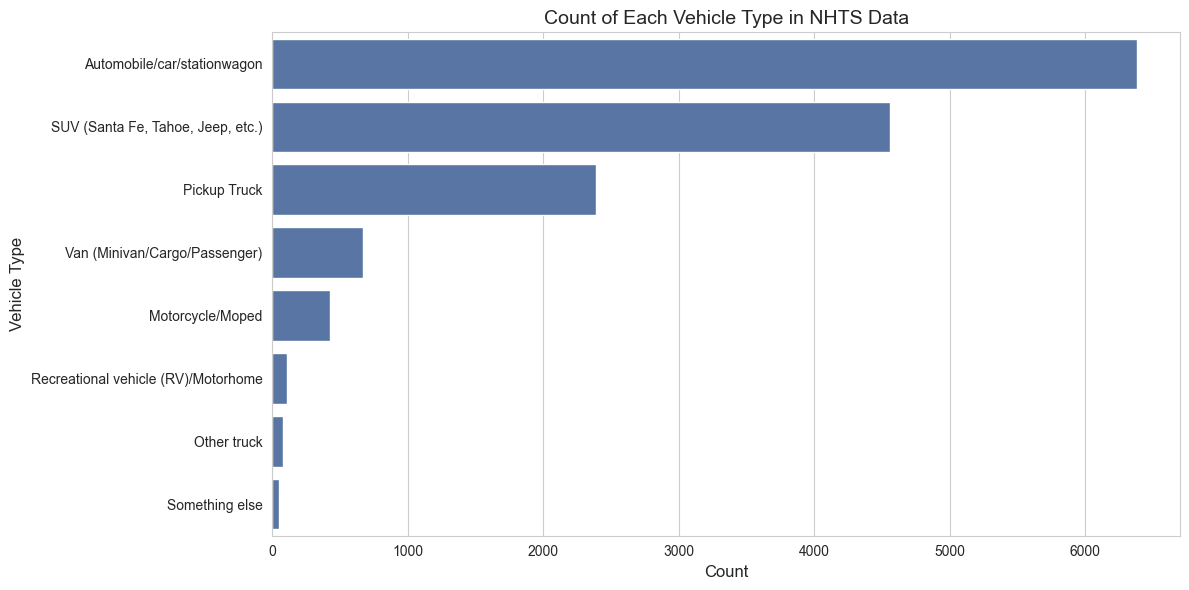

In [10]:
# Create a countplot showing the number of each vehicle type
# seaborn's countplot automatically counts the categories for you

## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize=(12, 6))  # Set the figure size

## Step 2: use sns.countplot to create the plot
# order sorts the bars from most frequent to least frequent
sns.countplot(data=nhts_data, y='vehicle_type', order=nhts_data['vehicle_type'].value_counts().index)

## Step 3: add labels and title
plt.xlabel('Count', fontsize=12)
plt.ylabel('Vehicle Type', fontsize=12)
plt.title('Count of Each Vehicle Type in NHTS Data', fontsize=14)
plt.tight_layout()  # Adjust layout to prevent clipping of labels

## Step 4: show the plot
plt.show()

### 3.2 – Histogram: Distribution of Vehicle Ages

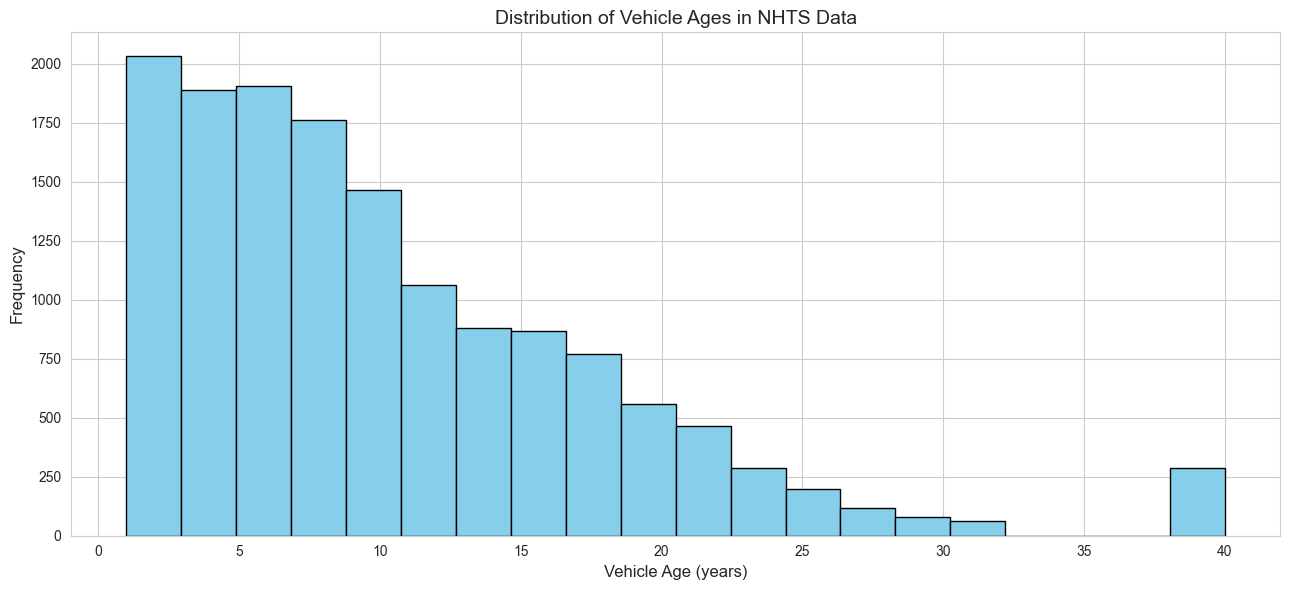

In [ ]:
# Matplotlib to create a histogram of vehicle ages

## Step 1: Tell Python you are plotting a figure and how big you want the figure to be
plt.figure(figsize=(13, 6))

## Step 2: Tell Python what type of plot you want. .hist() creates a histogram
# bins=20 splits the data into 20 equal-width bins
# color sets the bar fill, edgecolor outlines each bar in black
plt.hist(nhts_data['vehicle_age'], bins=20, color='skyblue', edgecolor='black')

## Labels
plt.xlabel('Vehicle Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Vehicle Ages in NHTS Data', fontsize=14)

## Step 4: show the plot
plt.tight_layout()
plt.show()

### 3.3 – Box Plot: Vehicles per Household by Census Region

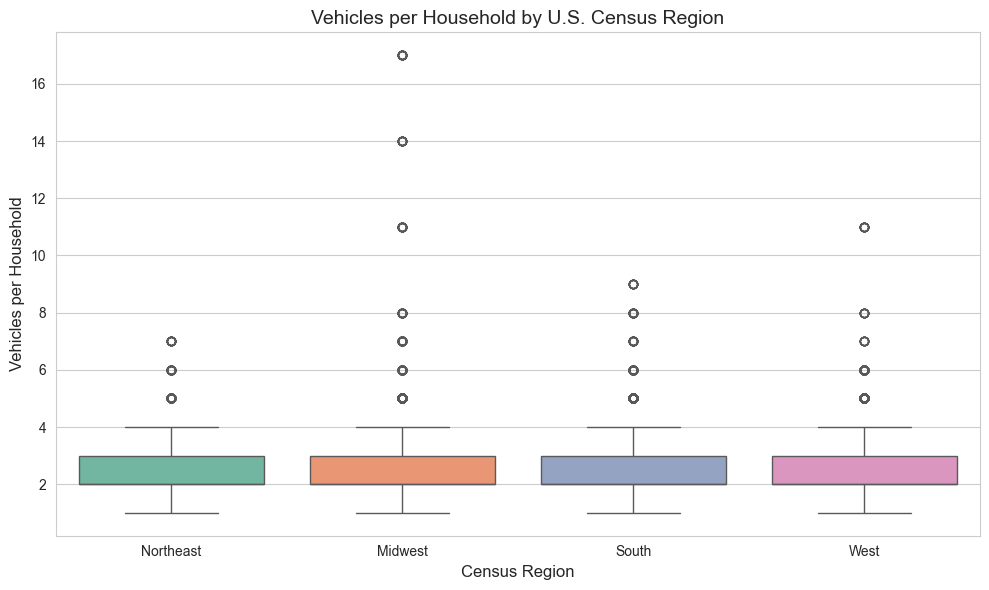

In [12]:
# Create a boxplot to visualize vehicles per household grouped by census region
# The box shows the median (center line), IQR (box edges), and outliers (dots)

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize=(10, 6))  # Set the figure size

## Step 2: call the type of plot and tell the function what variables you want to plot
# x = categorical variable (census_region), y = continuous variable (vehicles_per_household)
sns.boxplot(data=nhts_data, x='census_region', y='vehicles_per_household', 
            hue='census_region', palette='Set2', legend=False)

## Step 3: add customization to the plot
plt.xlabel('Census Region', fontsize=12)
plt.ylabel('Vehicles per Household', fontsize=12)
plt.title('Vehicles per Household by U.S. Census Region', fontsize=14)

## Step 4: tell python to show the plot
plt.tight_layout()
plt.show()

### 3.4 – Bar Chart: Count of Vehicles by Fuel Type

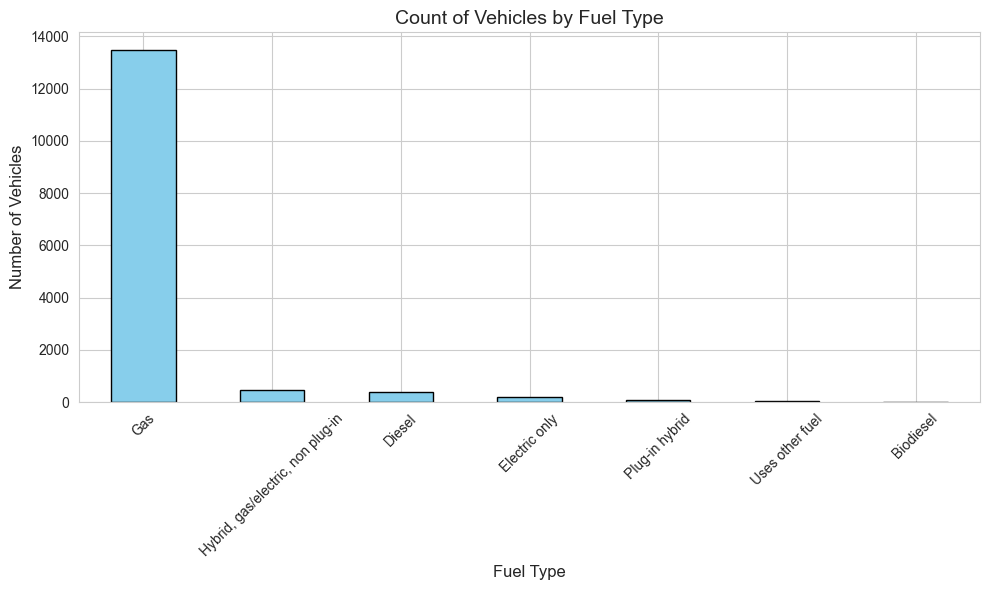

In [13]:
# Simple bar chart: count of vehicles by fuel type
# First we need to count the values, then plot

## Step 1: count the number of vehicles by fuel type
# use .value_counts() and drop NaN values if they exist
fuel_counts = nhts_data['fuel_type'].value_counts().dropna()

## Step 2: create the bar plot
plt.figure(figsize=(10, 6))
fuel_counts.plot(kind='bar', color='skyblue', edgecolor='black')

## Step 3: add labels and customization
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.title('Count of Vehicles by Fuel Type', fontsize=14)
plt.xticks(rotation=45)

## Step 4: show the plot
plt.tight_layout()
plt.show()

---
## Section 4: NGSIM Time-Series Visualizations
These plots fulfill the client's requirement for **at least two time-series plots** showing and analyzing driving behavior.

### 4.1 – Leader Acceleration vs Time (All Trajectories)

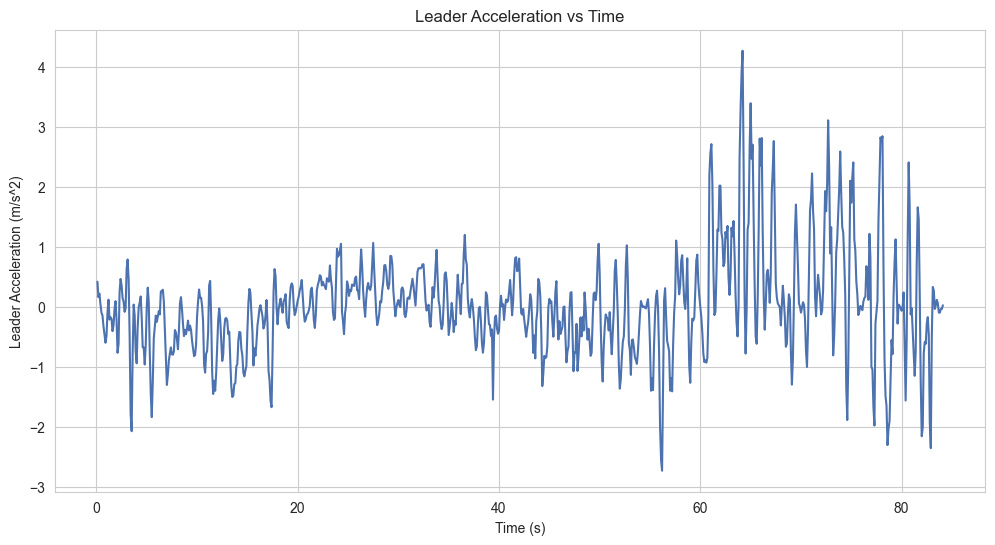

In [15]:
# Plotting Acceleration vs Time
# We are interested in analyzing the acceleration profile of the leader vehicles as function of time

## Step 1: tell python that you want to plot and assign a size
plt.figure(figsize=(12, 6))

## Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and leader_acc (y-axis)
sns.lineplot(data=ngsim_data, x='Time', y='leader_acc(m/s^2)', errorbar=None)

## Step 3: add customizations
plt.title('Leader Acceleration vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Leader Acceleration (m/s^2)')

## Step 4: show the plot
plt.show()

### 4.2 – Follower Speed vs Time (All Trajectories, Colored by Pair)

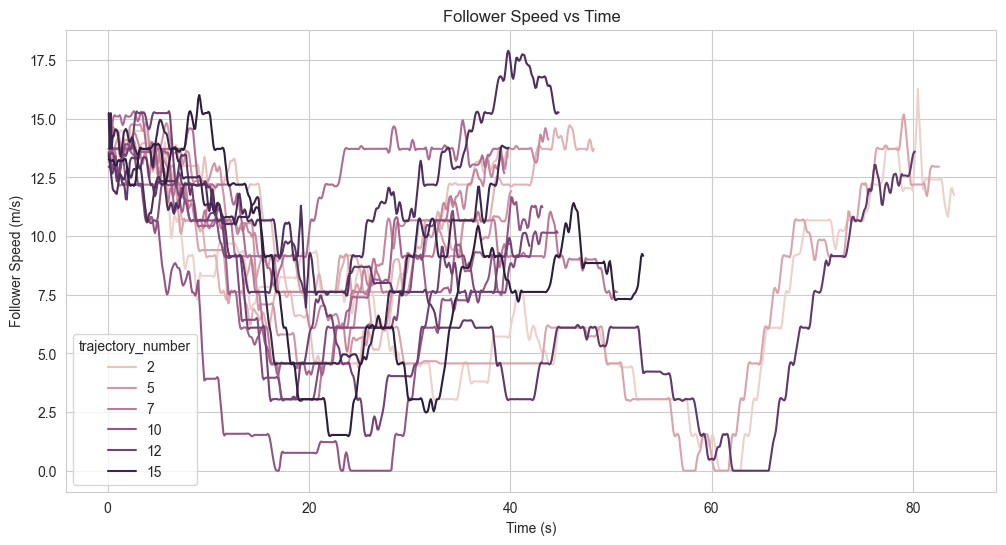

In [16]:
# Plotting Speed vs Time
# Each trajectory pair gets its own colored line using hue

## Step 1: tell python that you want to plot and assign a size
plt.figure(figsize=(12, 6))

## Step 2: use sns.lineplot with hue to color each trajectory differently
sns.lineplot(data=ngsim_data, x='Time', y='follower_speed(m/s)', hue='trajectory_number')

## Step 3: add customizations
plt.title('Follower Speed vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Follower Speed (m/s)')

## Step 4: show the plot
plt.show()

### 4.3 – Single Trajectory Pair Analysis (Trajectory 3)
We want to choose a specific vehicle pair and analyze their behavior.  
In traffic studies, this is referred to as car-following analysis: how one vehicle follows another in traffic.

In [17]:
# Select a trajectory number
trajectory_number = 3  # vehicle pair 3

# select the data based on the subset
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

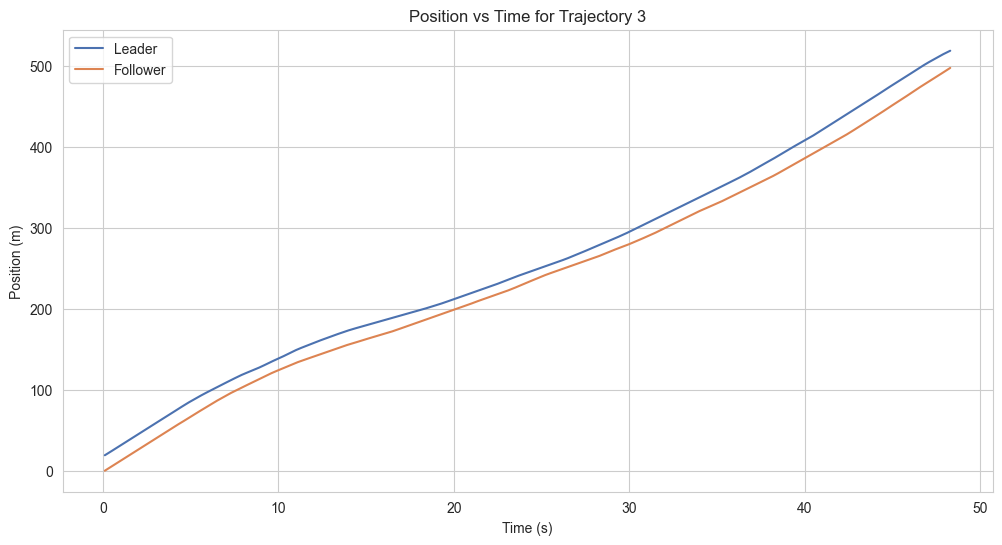

In [18]:
# Plot the position of both vehicles over time
# here you need to plot two lines together:
    # one lineplot for leader position vs time
    # another lineplot for follower position vs time

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_subset, x='Time', y='leader_position(m)', label='Leader')
sns.lineplot(data=data_subset, x='Time', y='follower_position(m)', label='Follower')
plt.title(f'Position vs Time for Trajectory {trajectory_number}')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.show()

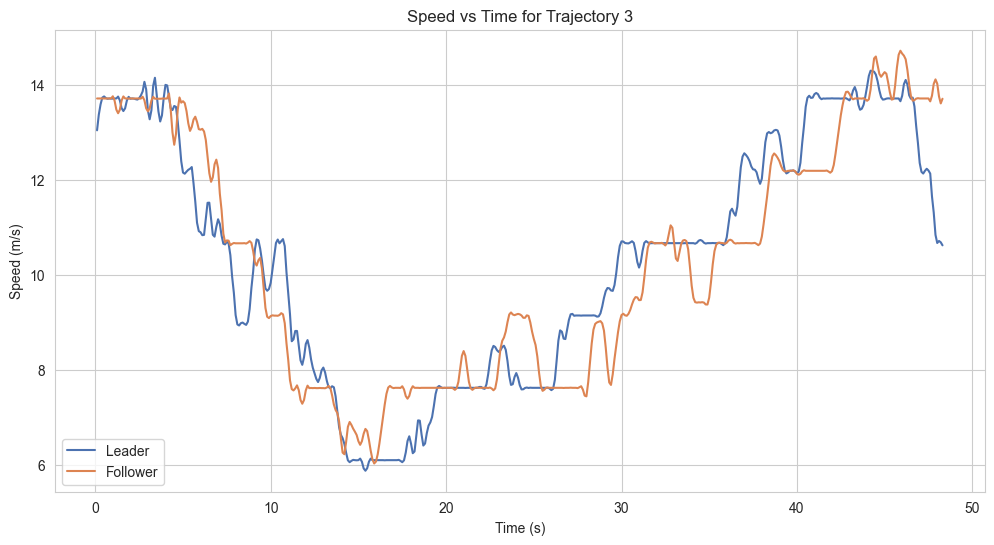

In [19]:
# Now replicate the same but visualizing speed

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_subset, x='Time', y='leader_speed(m/s)', label='Leader')
sns.lineplot(data=data_subset, x='Time', y='follower_speed(m/s)', label='Follower')
plt.title(f'Speed vs Time for Trajectory {trajectory_number}')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.show()

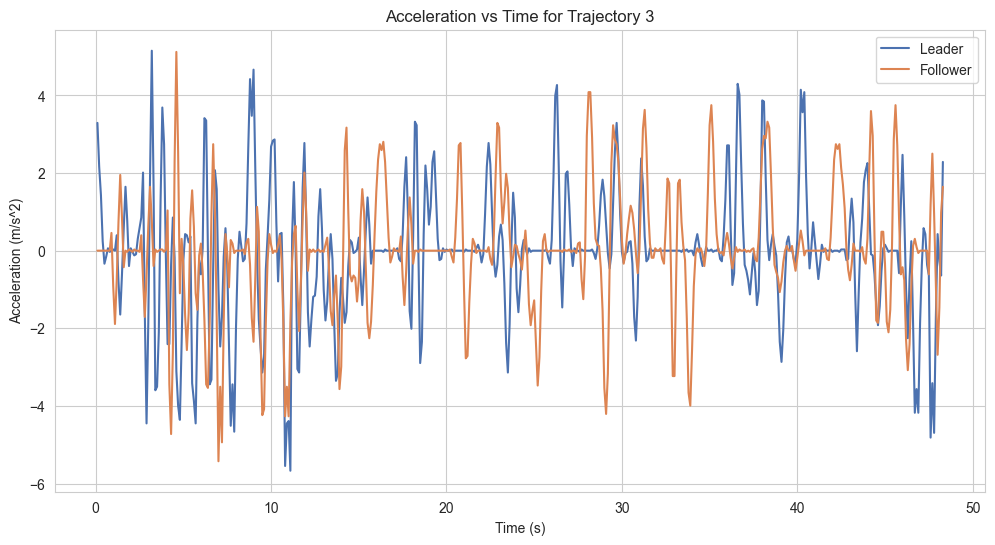

In [20]:
# Now replicating the same but visualizing acceleration

plt.figure(figsize=(12, 6))
sns.lineplot(data=data_subset, x='Time', y='leader_acc(m/s^2)', label='Leader')
sns.lineplot(data=data_subset, x='Time', y='follower_acc(m/s^2)', label='Follower')
plt.title(f'Acceleration vs Time for Trajectory {trajectory_number}')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.show()

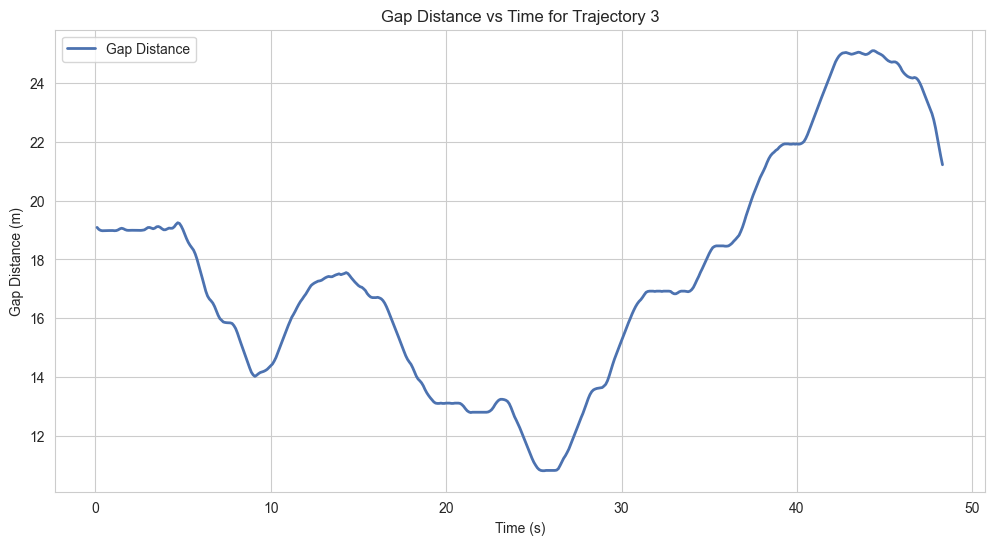

In [21]:
# Now try to plot the gap distance between two vehicle pairs
# Gap = position of leader - position of follower

plt.figure(figsize=(12, 6))
plt.plot(data_subset['Time'], data_subset['leader_position(m)'] - data_subset['follower_position(m)'], 
         label='Gap Distance', linewidth=2)
plt.title(f'Gap Distance vs Time for Trajectory {trajectory_number}')
plt.xlabel('Time (s)')
plt.ylabel('Gap Distance (m)')
plt.legend()
plt.show()

### 4.4 – Comprehensive Vehicle Pair Dashboard (Customized)
A 2×2 subplot showing position, speed, acceleration, and gap for trajectory 3.  
This demonstrates customization: custom colors, transparency, line width, and rearranged subplots.

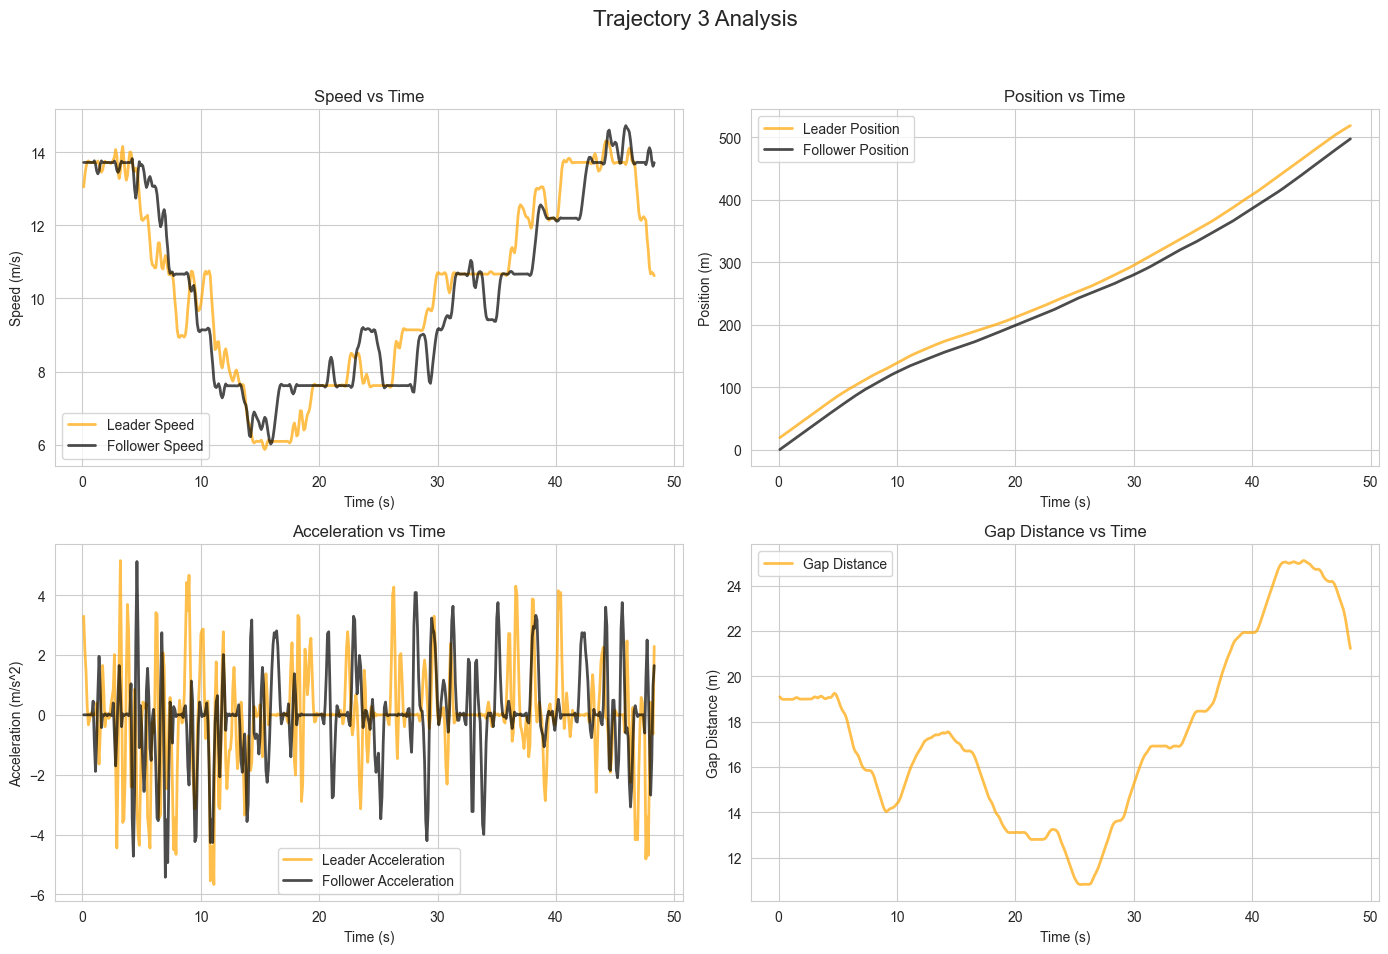

In [22]:
# Create a 2x2 subplot figure showing: trajectory, speed, acceleration, and gap for one vehicle pair

# Step 1: Select a trajectory number and create the subset
trajectory_number = 3
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values
aplha = 0.7  # transparency value for the lines

# Step 2: Create the figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Step 3: Top-left (axes[0,0]): Speed vs Time for both leader and follower
axes[0, 0].plot(time, data_subset['leader_speed(m/s)'].values, label='Leader Speed', linewidth=2, color='orange', alpha=aplha)
axes[0, 0].plot(time, data_subset['follower_speed(m/s)'].values, label='Follower Speed', linewidth=2, color='black', alpha=aplha)
axes[0, 0].set_title('Speed vs Time')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Speed (m/s)')
axes[0, 0].legend()

# Step 4: Top-right (axes[0,1]): Position vs Time for both leader and follower
axes[0, 1].plot(time, data_subset['leader_position(m)'].values, label='Leader Position', linewidth=2, color='orange', alpha=aplha)
axes[0, 1].plot(time, data_subset['follower_position(m)'].values, label='Follower Position', linewidth=2, color='black', alpha=aplha)
axes[0, 1].set_title('Position vs Time')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Position (m)')
axes[0, 1].legend()

# Step 5: Bottom-left (axes[1,0]): Acceleration vs Time for both leader and follower
axes[1, 0].plot(time, data_subset['leader_acc(m/s^2)'].values, label='Leader Acceleration', linewidth=2, color='orange', alpha=aplha)
axes[1, 0].plot(time, data_subset['follower_acc(m/s^2)'].values, label='Follower Acceleration', linewidth=2, color='black', alpha=aplha)
axes[1, 0].set_title('Acceleration vs Time')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Acceleration (m/s^2)')
axes[1, 0].legend()

# Step 6: Bottom-right (axes[1,1]): Gap Distance vs Time
axes[1, 1].plot(time, gap_distance, label='Gap Distance', linewidth=2, color='orange', alpha=aplha)
axes[1, 1].set_title('Gap Distance vs Time')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Gap Distance (m)')
axes[1, 1].legend()

# Step 7: Add title for the whole figure and adjust layout
fig.suptitle(f'Trajectory {trajectory_number} Analysis', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## Section 5: Intelligent Driver Model (IDM) Simulation
The IDM models car-following behavior by computing a follower vehicle's acceleration based on its speed, the gap to the leader, and the speed difference.

### 5.1 – Define the IDM Acceleration Function

In [23]:
# Define the IDM acceleration function
# The function takes the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))

    # Make sure s_star is not negative
    s_star = max(s_star, s0)

    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)

    return acceleration

### 5.2 – Test the IDM Function

In [24]:
# Test the IDM function with sample values
# A follower traveling at 20 m/s, with a gap of 25 m, approaching the leader at 2 m/s

# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Test case
test_v = 20        # follower speed
test_s = 25        # gap distance
test_delta_v = 2   # follower is faster than leader by 2 m/s

# Call the function and print the result
test_acc = idm_acceleration(test_v, test_s, test_delta_v, v0, s0, T, a, b, delta)
print("Calculated acceleration:", test_acc)

# Think about: does this value make sense? The follower is approaching the leader, so should it accelerate or decelerate?

Calculated acceleration: -2.9347825286041807


### 5.3 – Set Up the Simulation

In [37]:
# Load the NGSIM data to get the leader vehicle trajectory
# We already loaded ngsim_data above, so we just need to select a trajectory

# Select a trajectory pair
trajectory_number = 3
data_subset_sim = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

# Extract the leader's position and speed over time
time_data = data_subset_sim['Time'].values
leader_speed = data_subset_sim['leader_speed(m/s)'].values
leader_position = data_subset_sim['leader_position(m)'].values

# Identifying the time step in our data
dt = 0.1  # seconds

In [38]:
# Set the IDM parameters
v0 = 30        # desired velocity (m/s)
s0 = 2         # minimum spacing (m)
T = 1.5        # desired time headway (s)
a_param = 1.0  # maximum acceleration (m/s^2)
b = 1.5        # comfortable deceleration (m/s^2)
delta = 4      # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)  # number of simulation steps, equal to length of trajectory data
sim_position = np.zeros(n_steps)  # simulated follower position; create a vector with all zeroes as start
sim_speed = np.zeros(n_steps)     # simulated follower speed; create a vector with all zeroes as start
sim_acc = np.zeros(n_steps)       # simulated follower acceleration; create a vector with all zeroes as start

# Start at the real follower's initial state
sim_position[0] = data_subset_sim['follower_position(m)'].values[0]  # starting value same as real follower position
sim_speed[0] = data_subset_sim['follower_speed(m/s)'].values[0]      # starting value same as real follower speed

### 5.4 – Run the IDM Simulation

In [39]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1):  # we do -1 since the first element is known

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)  # gap should not be negative, min of 0.1 to avoid division by zero
    delta_v = sim_speed[i] - leader_speed[i]  # speed difference (positive if follower is faster)

    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0)  # speed can't go negative
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

print("Simulation complete!")

Simulation complete!


### 5.5 – Visualize the Simulation Results

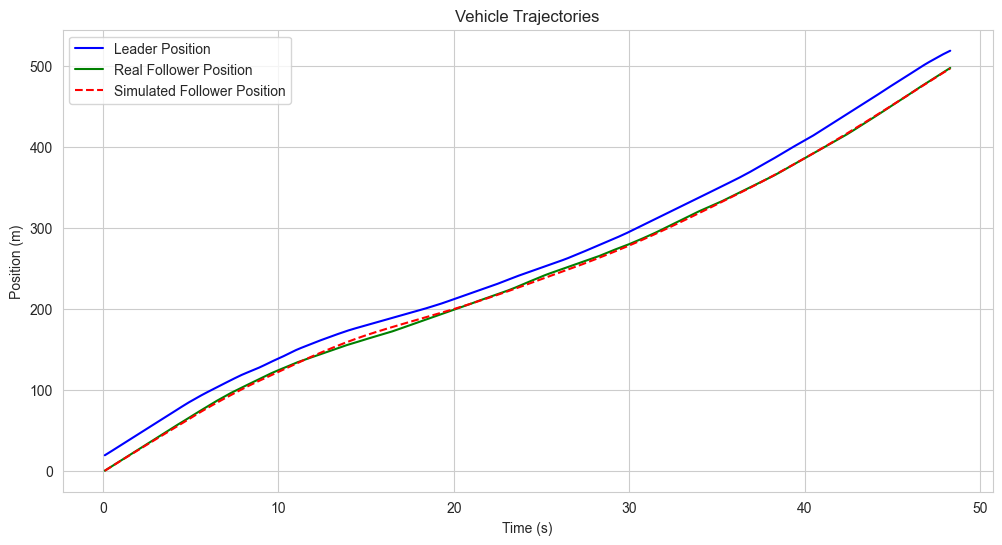

In [40]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower

plt.figure(figsize=(12, 6))
plt.plot(time_data, leader_position, label='Leader Position', color='blue')
plt.plot(time_data, data_subset_sim['follower_position(m)'].values, label='Real Follower Position', color='green')
plt.plot(time_data, sim_position, label='Simulated Follower Position', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Vehicle Trajectories')
plt.legend()
plt.grid(True)
plt.show()

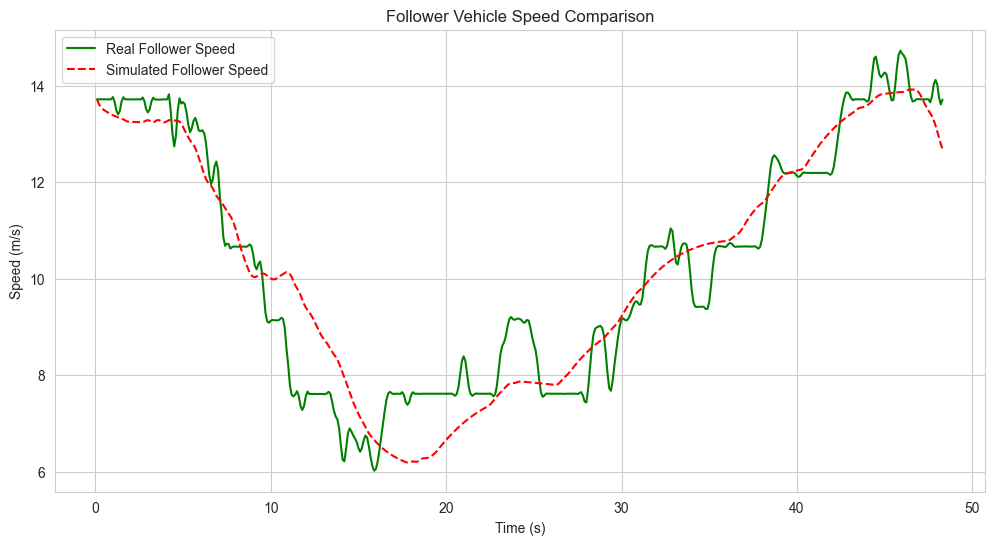

In [41]:
# Plot 2: Speed vs Time — Comparing real follower vs simulated follower

plt.figure(figsize=(12, 6))
plt.plot(time_data, data_subset_sim['follower_speed(m/s)'].values, label='Real Follower Speed', color='green')
plt.plot(time_data, sim_speed, label='Simulated Follower Speed', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Follower Vehicle Speed Comparison')
plt.legend()
plt.grid(True)
plt.show()

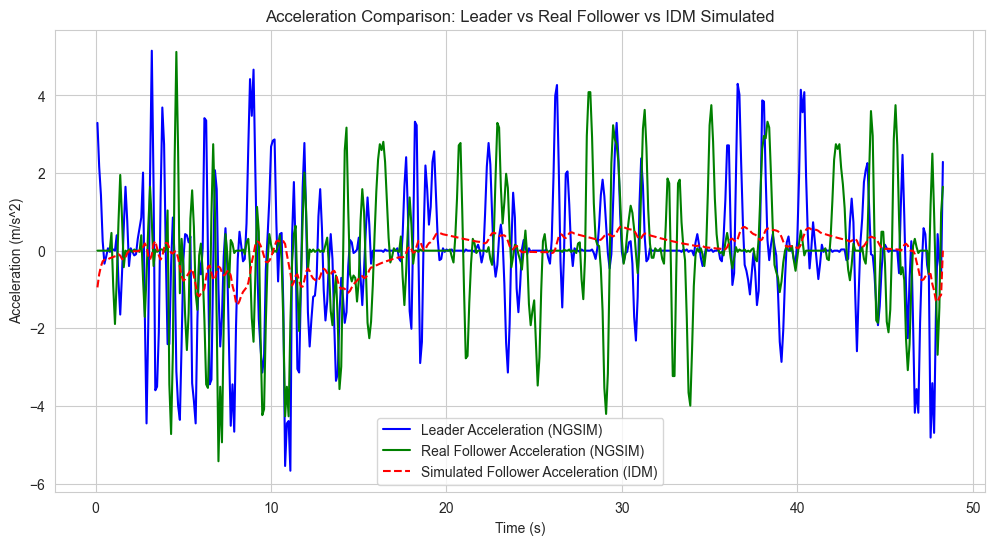

In [43]:
# Plot 4: Acceleration vs Time — Comparing leader, real follower, and simulated follower
# This fulfills the client requirement to simulate acceleration and show all three on one plot

plt.figure(figsize=(12, 6))
plt.plot(time_data, data_subset_sim['leader_acc(m/s^2)'].values, label='Leader Acceleration (NGSIM)', color='blue')
plt.plot(time_data, data_subset_sim['follower_acc(m/s^2)'].values, label='Real Follower Acceleration (NGSIM)', color='green')
plt.plot(time_data, sim_acc, label='Simulated Follower Acceleration (IDM)', color='red', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('Acceleration Comparison: Leader vs Real Follower vs IDM Simulated')
plt.legend()
plt.grid(True)
plt.show()

---
## Section 6: AI Use Citation

Anthropic. (2026). Claude (Claude Opus 4.6) [Large language model]. https://claude.ai

Claude was used to assist with combining lab notebooks into a single deliverable, writing code comments, structuring the notebook layout, and drafting portions of the written report. All code was reviewed, tested, and verified by the team before submission.